In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import sys 
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [ ]:
import src.preprocess as pp 

In [5]:
data = pp.load_raw_data()
data = pp.prepare_basic_dates(data)

train = data["train"]
test = data["test"]
stores = data["stores"]
oil = data["oil"]
holidays_events = data["holidays_events"]
transaction = data["transactions"]

In [6]:
print("\nTrain")
print(train.head())
print("\nTrain Shape: ")
print(train.shape)
print("\nTrain Columns: ")
print(train.columns)

print(train["date"].dtype)


Train
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

Train Shape: 
(3000888, 6)

Train Columns: 
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')
datetime64[ns]


In [12]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
oil["date"] = pd.to_datetime(oil["date"])
transaction["date"] = pd.to_datetime(transaction["date"])
print("\nTrain date's type: ")
print(train["date"].dtype)


Train date's type: 
datetime64[ns]


In [ ]:
train_merged = train.merge(stores, on="store_nbr", how="left") 
print("\n Train + Store's merge 's first 5 row: ")
print(train_merged.head())
print("\nShape: ")
print(train_merged.shape)


 Train + Store's merge 's first 5 row: 
   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  
0    D       13  
1    D       13  
2    D       13  
3    D       13  
4    D       13  

Shape: 
(3000888, 10)


In [14]:
train_merged = train_merged.merge(oil, on="date", how = "left")
print("\nTrain_merged + Oil's merge's first 5 rows: ")
print(train_merged.head())
print("\nShape: ")
print(train_merged.shape)


Train_merged + Oil's merge's first 5 rows: 
   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  dcoilwtico  
0    D       13         NaN  
1    D       13         NaN  
2    D       13         NaN  
3    D       13         NaN  
4    D       13         NaN  

Shape: 
(3000888, 11)


In [15]:
train_merged = train_merged.merge(oil, on="date", how = "left")
print("\nTrain_merged + Oil's merge's first 5 rows: ")
print(train_merged.head())
print("\nShape: ")
print(train_merged.shape)


Train_merged + Oil's merge's first 5 rows: 
   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  dcoilwtico_x  dcoilwtico_y  
0    D       13           NaN           NaN  
1    D       13           NaN           NaN  
2    D       13           NaN           NaN  
3    D       13           NaN           NaN  
4    D       13           NaN           NaN  

Shape: 
(3000888, 12)


In [ ]:
print("Uncompleted values: ")
print(train_merged.isnull().sum())

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
                  ...      
2017-08-11    826373.722022
2017-08-12    792630.535079
2017-08-13    865639.677471
2017-08-14    760922.406081
2017-08-15    762661.935939
Name: sales, Length: 1684, dtype: float64


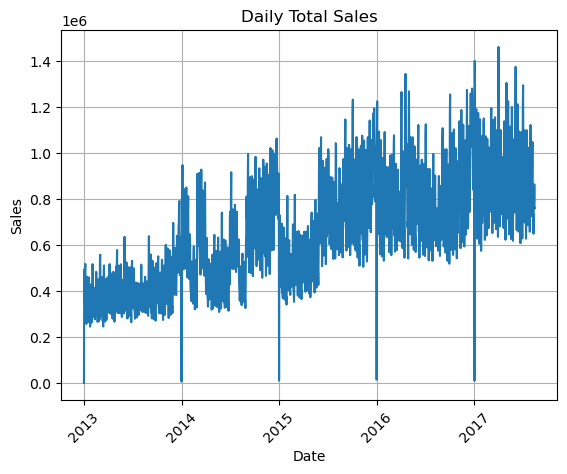

In [ ]:
daily_sales = train_merged.groupby("date")["sales"].sum()
print(daily_sales)
plt.figure()
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45) 
plt.grid()
plt.show()

city
Ambato           4.030440e+07
Babahoyo         1.774687e+07
Cayambe          2.832556e+07
Cuenca           4.916860e+07
Daule            1.918802e+07
El Carmen        1.105748e+07
Esmeraldas       1.639169e+07
Guaranda         1.304951e+07
Guayaquil        1.229673e+08
Ibarra           1.145127e+07
Latacunga        2.118226e+07
Libertad         1.532243e+07
Loja             1.886000e+07
Machala          3.338680e+07
Manta            1.391234e+07
Playas           7.676679e+06
Puyo             4.090202e+06
Quevedo          1.417850e+07
Quito            5.567418e+08
Riobamba         1.138792e+07
Salinas          1.142100e+07
Santo Domingo    3.583432e+07
Name: sales, dtype: float64


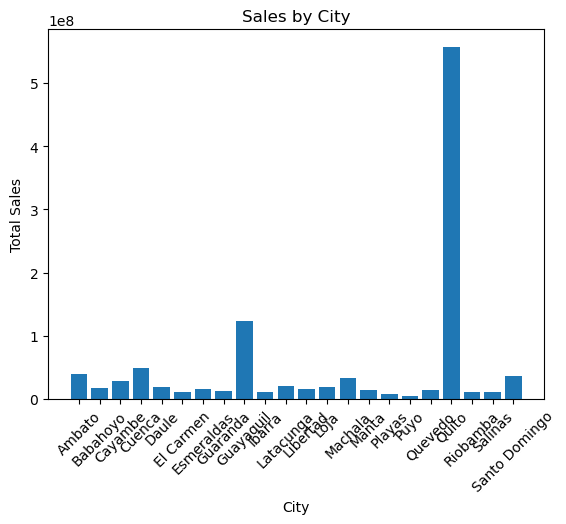

In [19]:
city_sales = train_merged.groupby("city")["sales"].sum()
print(city_sales)
plt.figure()
plt.bar(city_sales.index, city_sales.values)
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

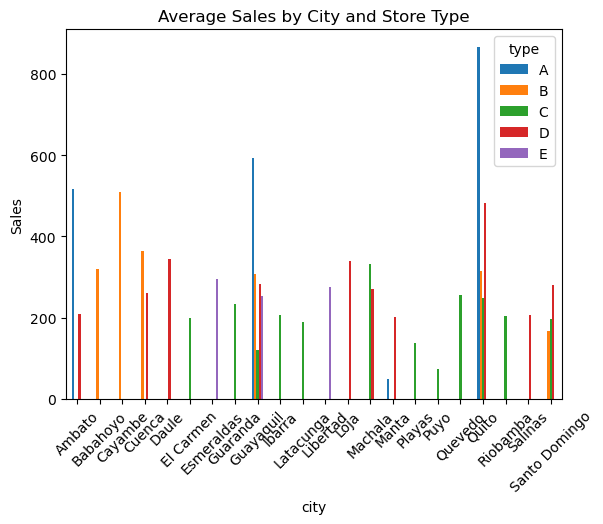

In [20]:
city_type = train_merged.groupby(["city" , "type"])["sales"].mean().unstack()
city_type.plot(kind="bar")
plt.title("Average Sales by City and Store Type")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.show()

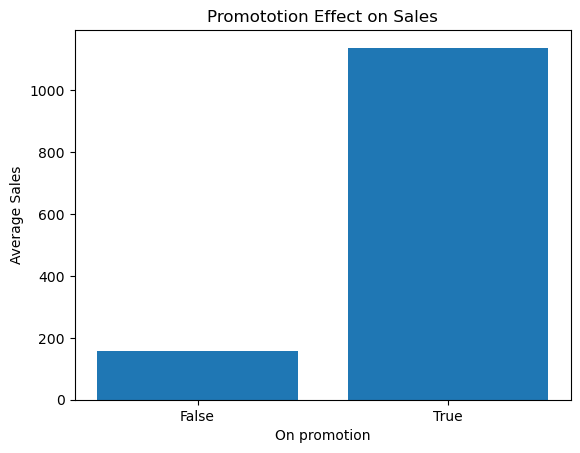

In [21]:
train_merged["promo_flag"] = train_merged["onpromotion"] > 0
promo_sales = train_merged.groupby("promo_flag")["sales"].mean()
plt.figure()
plt.bar(promo_sales.index.astype(str), promo_sales.values)
plt.title("Promototion Effect on Sales")
plt.xlabel("On promotion")
plt.ylabel("Average Sales")
plt.show()


/var/folders/tk/knmkn5ps4vg973_kj7_vjkkm0000gn/T/ipykernel_35618/2365225509.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_group = train_merged.groupby("promo_level")["sales"].mean()


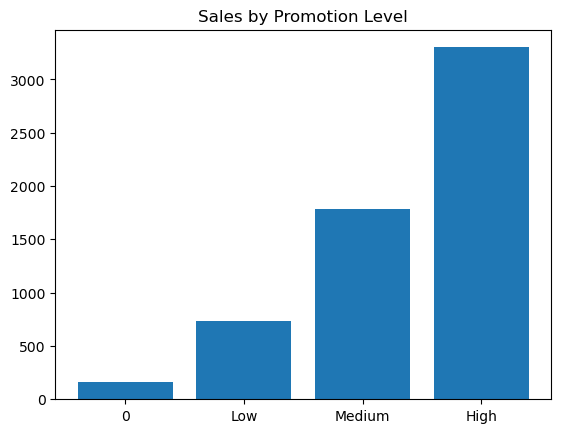

In [22]:
train_merged["promo_level"] = pd.cut(
    train_merged["onpromotion"],
    bins= [-1, 0, 10, 50, 100],
    labels = ["0", "Low", "Medium", "High"]
)
promo_group = train_merged.groupby("promo_level")["sales"].mean()

plt.figure()
plt.bar(promo_group.index.astype(str), promo_group.values)
plt.title("Sales by Promotion Level")
plt.show()

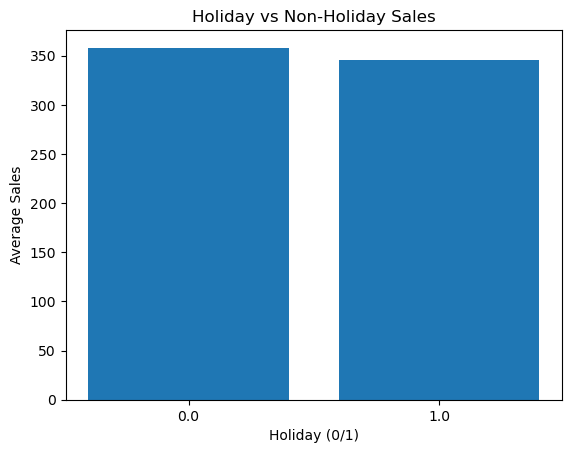

In [23]:
holiday_sales = train_merged.groupby("holiday_national_binary")["sales"].mean()
plt.figure()
plt.bar(holiday_sales.index.astype(str), holiday_sales.values)
plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday (0/1)")
plt.ylabel("Average Sales")
plt.show()

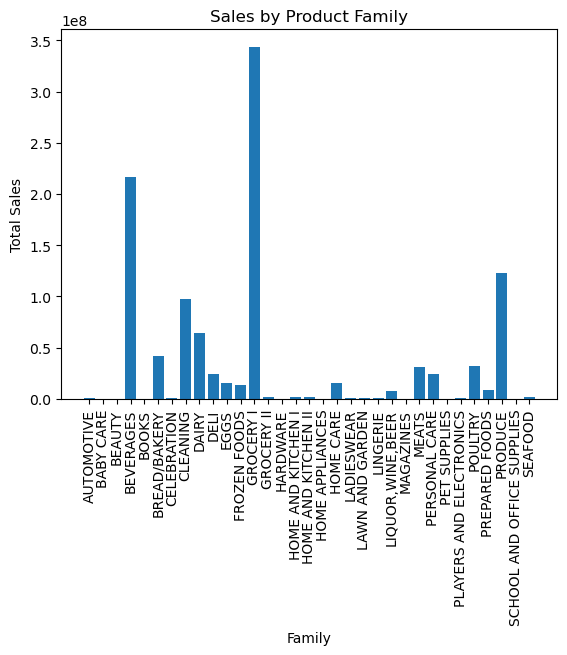

In [ ]:
family_sales = train_merged.groupby("family")["sales"].sum()
plt.figure()
plt.bar(family_sales.index, family_sales.values)
plt.title("Sales by Product Family")
plt.xlabel("Family")
plt.ylabel("Total Sales")
plt.xticks(rotation = 90) 
plt.show()